# Task 06：Actor-Critic 与 GAE——学习与实验入口

## 本 Notebook 的学习边界

Actor 产生策略，Critic 估计 $V(s)$。一步 TD residual 为：

$$
\delta_t=R_{t+1}+\gamma(1-d_t)V(S_{t+1})-V(S_t).
$$

n-step 和 GAE 通过不同时间范围的 residual 组织 advantage。先运行 one-step Actor-Critic，再运行 n-step 版本，最后比较学习曲线、actor loss、critic loss 和达到阈值的速度。


### Part A：one-step、n-step 与训练曲线

# Task 06：Actor-Critic 与 GAE——学习与实验入口

## 本 Notebook 的学习边界

Actor 产生策略，Critic 估计 $V(s)$。一步 TD residual 为：

$$
\delta_t=R_{t+1}+\gamma(1-d_t)V(S_{t+1})-V(S_t).
$$

n-step 和 GAE 通过不同时间范围的 residual 组织 advantage。先运行 one-step Actor-Critic，再运行 n-step 版本，最后比较学习曲线、actor loss、critic loss 和达到阈值的速度。


In [1]:
%load_ext autoreload
%autoreload 2

import sys
import random
from pathlib import Path
from collections import deque

import gymnasium as gym
import numpy as np
import torch
import matplotlib.pyplot as plt

sys.path.append(
    str(Path("../").resolve())
)

from src.actor_critic import ActorCriticAgent
from src.n_step_actor_critic import NStepActorCriticAgent

In [2]:
SEED = 42

NUM_EPISODES = 500

ACTOR_LR = 1e-4
CRITIC_LR = 5e-4

GAMMA = 0.99

HIDDEN_DIM = 128


np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
env = gym.make("CartPole-v1")

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

print("state_dim =", state_dim)
print("action_dim =", action_dim)

state_dim = 4
action_dim = 2


In [4]:
agent = ActorCriticAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=HIDDEN_DIM,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    gamma=GAMMA,
)

episode_returns = []

actor_losses = []
critic_losses = []
td_errors = []


for episode in range(NUM_EPISODES):

    state, _ = env.reset()

    episode_return = 0.0

    terminated = False
    truncated = False

    while not (
        terminated
        or truncated
    ):

        # ========================
        # 1. Actor 采样动作
        # ========================

        action = agent.select_action(
            state
        )

        # ========================
        # 2. Environment
        # ========================

        (
            next_state,
            reward,
            terminated,
            truncated,
            _
        ) = env.step(
            action
        )

        # ========================
        # 3. One-step AC
        #
        # 每一步立即更新
        # ========================

        info = agent.update(
            state=state,
            action=action,
            reward=reward,
            next_state=next_state,
            terminated=terminated,
        )

        # ========================
        # 4. Record
        # ========================

        episode_return += reward

        actor_losses.append(
            info["actor_loss"]
        )

        critic_losses.append(
            info["critic_loss"]
        )

        td_errors.append(
            info["td_error"]
        )

        state = next_state

    episode_returns.append(
        episode_return
    )

    # ========================
    # Log
    # ========================

    if (episode + 1) % 50 == 0:

        avg_return = np.mean(
            episode_returns[-50:]
        )

        print(
            f"Episode {episode + 1:4d} | "
            f"Average Return: "
            f"{avg_return:.2f}"
        )

Episode   50 | Average Return: 21.98
Episode  100 | Average Return: 23.98
Episode  150 | Average Return: 71.06
Episode  200 | Average Return: 116.00
Episode  250 | Average Return: 110.86
Episode  300 | Average Return: 252.42
Episode  350 | Average Return: 412.58
Episode  400 | Average Return: 427.64
Episode  450 | Average Return: 297.96
Episode  500 | Average Return: 339.96


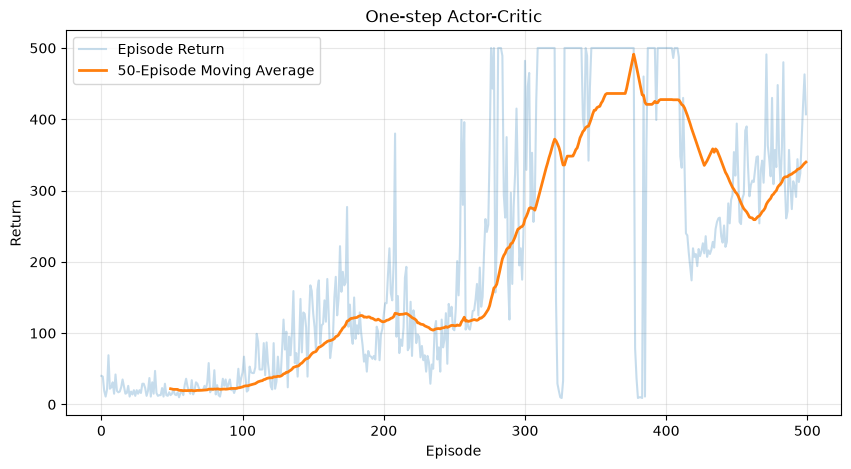

In [5]:
env.close()

returns = np.asarray(
    episode_returns,
    dtype=np.float32,
)

window = 50

moving_average = np.convolve(
    returns,
    np.ones(window) / window,
    mode="valid",
)


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    returns,
    alpha=0.25,
    label="Episode Return",
)

plt.plot(
    np.arange(
        window - 1,
        len(returns),
    ),
    moving_average,
    linewidth=2,
    label="50-Episode Moving Average",
)

plt.xlabel("Episode")
plt.ylabel("Return")

plt.title(
    "One-step Actor-Critic"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [6]:
print(
    "Best 50-Episode Average:",
    moving_average.max(),
)

print(
    "Final 100 Average:",
    np.mean(
        episode_returns[-100:]
    ),
)

Best 50-Episode Average: 491.28
Final 100 Average: 318.96


In [7]:
from collections import deque

from src.n_step_actor_critic import (
    NStepActorCriticAgent
)

N_STEPS = 5

ACTOR_LR = 1e-4
CRITIC_LR = 5e-4

GAMMA = 0.99

HIDDEN_DIM = 128

NUM_EPISODES = 500

env_5step = gym.make(
    "CartPole-v1"
)

state_dim = (
    env_5step.observation_space.shape[0]
)

action_dim = (
    env_5step.action_space.n
)


agent_5step = NStepActorCriticAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=HIDDEN_DIM,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    gamma=GAMMA,
)


episode_returns_5step = []

actor_losses_5step = []
critic_losses_5step = []
advantages_5step = []


for episode in range(
    NUM_EPISODES
):

    state, _ = env_5step.reset()

    terminated = False
    truncated = False

    episode_return = 0.0

    # =========================================================
    # 保存最近 n 个 transition
    # =========================================================

    buffer = deque()

    while not (
        terminated
        or truncated
    ):

        # =====================================================
        # 1. Actor 选择动作
        # =====================================================

        action = agent_5step.select_action(
            state
        )

        # =====================================================
        # 2. Environment
        # =====================================================

        (
            next_state,
            reward,
            terminated,
            truncated,
            _
        ) = env_5step.step(
            action
        )

        episode_return += reward

        # =====================================================
        # 3. 保存 transition
        # =====================================================

        buffer.append(
            (
                state,
                action,
                reward,
                next_state,
                terminated,
            )
        )

        # =====================================================
        # 4. buffer 中已经有 5 步
        #
        # 更新最前面的：
        #
        # (s_t, a_t)
        # =====================================================

        if len(buffer) >= N_STEPS:

            first_state = (
                buffer[0][0]
            )

            first_action = (
                buffer[0][1]
            )

            window = list(buffer)[:N_STEPS]

            rewards = [
                transition[2]
                for transition in window
            ]

            bootstrap_state = (
                window[-1][3]
            )

            bootstrap_terminated = (
                window[-1][4]
            )

            info = agent_5step.update(
                state=first_state,
                action=first_action,
                rewards=rewards,
                bootstrap_state=bootstrap_state,
                terminated=bootstrap_terminated,
            )

            actor_losses_5step.append(
                info["actor_loss"]
            )

            critic_losses_5step.append(
                info["critic_loss"]
            )

            advantages_5step.append(
                info["advantage"]
            )

            # =================================================
            # 窗口向前滑一步
            # =================================================

            buffer.popleft()

        state = next_state

    # =========================================================
    # Episode 结束后：
    #
    # buffer 里通常还剩最后几个 transition
    #
    # 不能扔掉
    # =========================================================

    while len(buffer) > 0:

        first_state = (
            buffer[0][0]
        )

        first_action = (
            buffer[0][1]
        )

        rewards = [
            transition[2]
            for transition in buffer
        ]

        bootstrap_state = (
            buffer[-1][3]
        )

        bootstrap_terminated = (
            buffer[-1][4]
        )

        info = agent_5step.update(
            state=first_state,
            action=first_action,
            rewards=rewards,
            bootstrap_state=bootstrap_state,
            terminated=bootstrap_terminated,
        )

        actor_losses_5step.append(
            info["actor_loss"]
        )

        critic_losses_5step.append(
            info["critic_loss"]
        )

        advantages_5step.append(
            info["advantage"]
        )

        buffer.popleft()

    # =========================================================
    # Episode Return
    # =========================================================

    episode_returns_5step.append(
        episode_return
    )

    if (
        episode + 1
    ) % 50 == 0:

        avg_return = np.mean(
            episode_returns_5step[-50:]
        )

        print(
            f"[5-step] "
            f"Episode {episode + 1:4d} | "
            f"Average Return: "
            f"{avg_return:.2f}"
        )


env_5step.close()

[5-step] Episode   50 | Average Return: 22.92
[5-step] Episode  100 | Average Return: 32.86
[5-step] Episode  150 | Average Return: 96.98
[5-step] Episode  200 | Average Return: 196.90
[5-step] Episode  250 | Average Return: 338.96
[5-step] Episode  300 | Average Return: 483.92
[5-step] Episode  350 | Average Return: 490.14
[5-step] Episode  400 | Average Return: 478.60
[5-step] Episode  450 | Average Return: 497.20
[5-step] Episode  500 | Average Return: 361.10


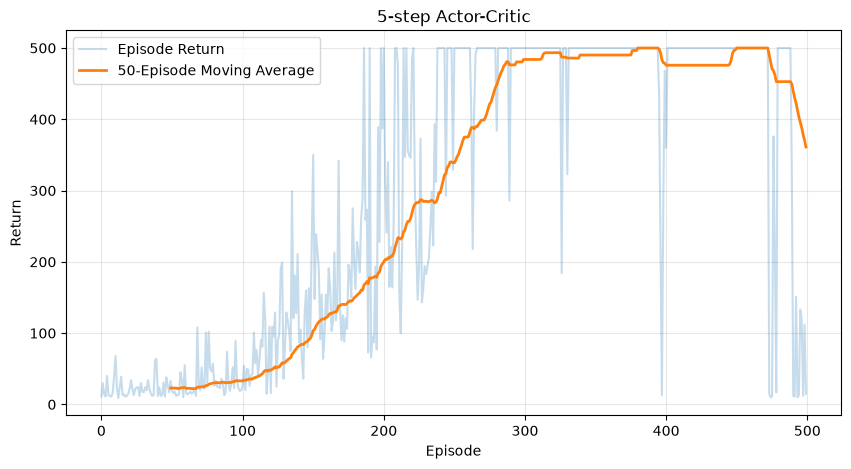

In [8]:
returns_5step = np.asarray(
    episode_returns_5step,
    dtype=np.float32,
)

window = 50

moving_average_5step = np.convolve(
    returns_5step,
    np.ones(window) / window,
    mode="valid",
)


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    returns_5step,
    alpha=0.25,
    label="Episode Return",
)

plt.plot(
    np.arange(
        window - 1,
        len(returns_5step),
    ),
    moving_average_5step,
    linewidth=2,
    label="50-Episode Moving Average",
)

plt.xlabel("Episode")
plt.ylabel("Return")

plt.title(
    "5-step Actor-Critic"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

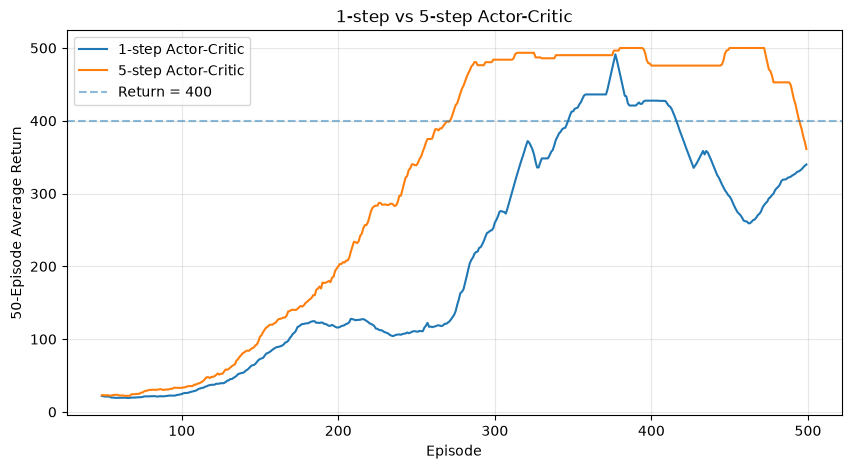

In [9]:
plt.figure(
    figsize=(10, 5)
)


# One-step
plt.plot(
    np.arange(
        window - 1,
        len(episode_returns),
    ),
    moving_average,
    label="1-step Actor-Critic",
)


# Five-step
plt.plot(
    np.arange(
        window - 1,
        len(episode_returns_5step),
    ),
    moving_average_5step,
    label="5-step Actor-Critic",
)


plt.axhline(
    400,
    linestyle="--",
    alpha=0.5,
    label="Return = 400",
)


plt.xlabel(
    "Episode"
)

plt.ylabel(
    "50-Episode Average Return"
)

plt.title(
    "1-step vs 5-step Actor-Critic"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()

In [12]:
def first_reach_threshold(
    returns,
    threshold=400,
    window=50,
):
    ma = np.convolve(
        np.asarray(returns),
        np.ones(window) / window,
        mode="valid",
    )

    idx = np.where(ma >= threshold)[0]

    if len(idx) == 0:
        return None

    return int(idx[0] + window)


print("===== Task 6 Final Comparison =====")

print(
    f"1-step Best 50-Episode Average: "
    f"{moving_average.max():.2f}"
)

print(
    f"5-step Best 50-Episode Average: "
    f"{moving_average_5step.max():.2f}"
)

print()

print(
    f"1-step Final 100 Average: "
    f"{np.mean(episode_returns[-100:]):.2f}"
)

print(
    f"5-step Final 100 Average: "
    f"{np.mean(episode_returns_5step[-100:]):.2f}"
)

print()

print(
    "1-step first reach 400:",
    first_reach_threshold(
        episode_returns,
        threshold=400,
    )
)

print(
    "5-step first reach 400:",
    first_reach_threshold(
        episode_returns_5step,
        threshold=400,
    )
)

===== Task 6 Final Comparison =====
1-step Best 50-Episode Average: 491.28
5-step Best 50-Episode Average: 500.00

1-step Final 100 Average: 318.96
5-step Final 100 Average: 429.15

1-step first reach 400: 348
5-step first reach 400: 273


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```


## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
